In [2]:
import os, sys
os.environ.setdefault('CONDA_PREFIX', sys.prefix)
os.environ.get('CONDA_PREFIX')

'C:\\Anaconda\\envs\\projectGDS'

In [3]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
import numpy as np
import sys

In [4]:
import pandas as pd

from importlib import reload


In [5]:
data = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\99950stemmedOvr.csv", index_col=0)
data.shape

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\hsfac\AppData\Local\Temp\ipykernel_30468\1521567455.py:1: SyntaxWarning: invalid escape sequence '\K'
  data = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\99950stemmedOvr.csv", index_col=0)


(994988, 1)

In [6]:
full_data = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\995,000_rows.csv")
metadata=full_data["type"]
metadata_domain=full_data["domain"]

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\hsfac\AppData\Local\Temp\ipykernel_30468\4181354930.py:1: SyntaxWarning: invalid escape sequence '\K'
  full_data = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\995,000_rows.csv")
C:\Users\hsfac\AppData\Local\Temp\ipykernel_30468\4181354930.py:1: DtypeWarning: Columns (0: Unnamed: 0, 1: id) have mixed types. Specify dtype option on import or set low_memory=False.
  full_data = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\995,000_rows.csv")


In [7]:
vocab_list = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\dataprocessing\\topwords10000.csv")

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\hsfac\AppData\Local\Temp\ipykernel_30468\3703769310.py:1: SyntaxWarning: invalid escape sequence '\K'
  vocab_list = pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\dataprocessing\\topwords10000.csv")


In [8]:
def change_label(label):
    if label in ["fake","hate","rumor","unreliable","conspiracy","bias","junksci","satire"]:
        return 0
    elif label in ["reliable","political","clickbait"]:
        return 1
    """
    if label in ["fake","clickbait","hate","rumor","unreliable","conspiracy","unknown"]:
        return "fake"
    else:
        return "reliable"
    """

In [9]:
metadata_values = metadata.apply(change_label)

In [10]:
temp=pd.Series(metadata_values)
temp
print(metadata_domain.shape)
temp2=pd.Series(metadata_domain)
print(temp.unique())

(995000,)
[ 1.  0. nan]


In [11]:
data["type"] = temp
data["domain"]=temp2
data=data.dropna(subset=["type"])

In [12]:
data=data.sample(frac=1,random_state=0)

In [13]:
data_training = data[0:int(len(data)*0.8)]
data_validation = data[int(len(data)*0.8):int(len(data)*0.9)]
data_testing = data[int(len(data)*0.9):]

In [14]:
vocab_words = vocab_list.index.to_numpy()
vocab_words=vocab_list["content"].tolist()

In [15]:
vectorizer = CountVectorizer(vocabulary=vocab_words)
vectorizer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [16]:
X = vectorizer.transform(data_training["content"])
y = data_training["type"]
#analyze = vectorizer.build_analyzer()

In [17]:
model = LogisticRegression(max_iter=2500)
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
sample_test = data_training["type"].iloc[:20]

In [20]:
predict_test = X[:20, :]

In [21]:
sample_predict = model.predict(predict_test)

In [22]:
true_y = data_validation["type"]
pred_y = model.predict(vectorizer.transform(data_validation["content"]))

In [48]:
print(f1_score(true_y, pred_y, average="binary"))

0.8518531351420024


In [24]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [25]:
conf_ma=confusion_matrix(true_y,pred_y)

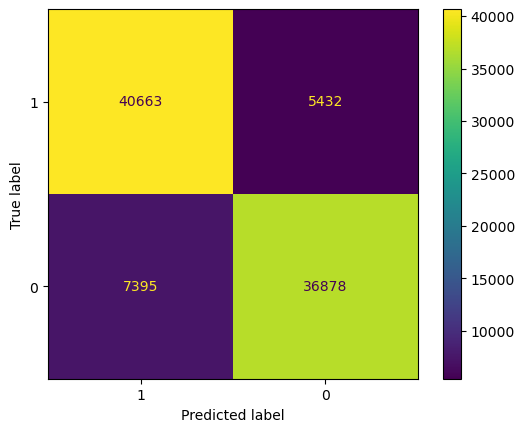

In [26]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma,display_labels=[1,0])
disp.plot()

plt.show()

In [27]:
data_plus_meta=data
data_plus_meta=data_plus_meta.dropna(subset=["domain"])
data_plus_meta["content"]=data_plus_meta["content"]+data_plus_meta["domain"]
vocab_list_domain=vocab_words+(list(data_plus_meta["domain"].unique()))

In [28]:
data_training2 = data_plus_meta[0:int(len(data)*0.8)]
data_validation2 = data_plus_meta[int(len(data)*0.8):int(len(data)*0.9)]
data_testing2 = data_plus_meta[int(len(data)*0.9):]

In [29]:
vocab_list_domain=(pd.Series(vocab_list_domain).drop_duplicates()).to_list()

In [30]:
vectorizer2=CountVectorizer(vocabulary=vocab_list_domain)


In [31]:
X2 = vectorizer2.transform(data_training2["content"])
y2=data_training2["type"]

In [32]:
model2=clf2 = LogisticRegression(random_state=0,max_iter=2500).fit(X2, y2)

In [33]:
true_y2 = data_validation2["type"]
pred_y2 = model2.predict(vectorizer2.transform(data_validation2["content"]))

In [47]:
print(f1_score(true_y2, pred_y2, average="binary"))

0.8648213820373665


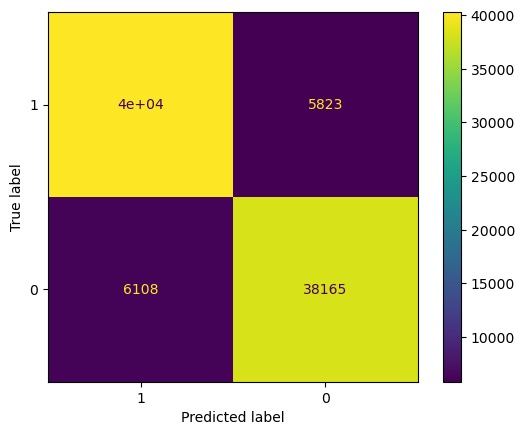

In [35]:
conf_ma=confusion_matrix(true_y2,pred_y2)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma,display_labels=[1,0])
disp.plot()

plt.show()

In [36]:
import joblib

In [37]:
joblib.dump(model,"linreg.joblib")

['linreg.joblib']

# Evaluation part

In [42]:
data_testing.to_csv("data_test.csv")

In [38]:
test_eval= model.predict(vectorizer.transform(data_testing["content"]))

In [46]:
print(f1_score(data_testing["type"],test_eval,average="binary"))

0.8509516700877029


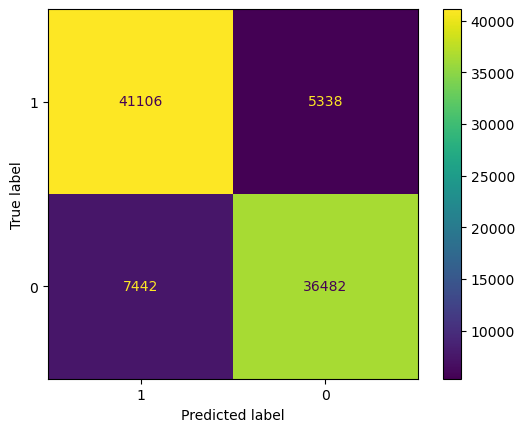

In [40]:
conf_ma=confusion_matrix(data_testing["type"],test_eval)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma,display_labels=[1,0])
disp.plot()

plt.show()

## LIAR

0.24582701062215478


<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\hsfac\AppData\Local\Temp\ipykernel_30468\191143236.py:1: SyntaxWarning: invalid escape sequence '\K'
  lair_data=pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\evaluation\lair_data_cleaned.csv")


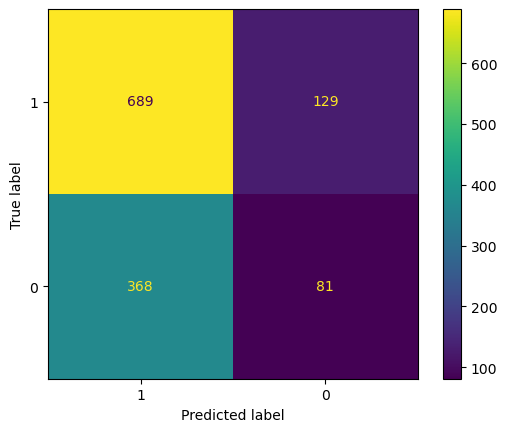

In [45]:
lair_data=pd.read_csv("E:\KU_MachineLearning_Study\Fake_news_project\Group-Fake-News-Project\evaluation\lair_data_cleaned.csv")
lair_eval=model.predict(vectorizer.transform(lair_data["content"]))
print(f1_score(lair_data["type"],lair_eval,average="binary"))
conf_ma=confusion_matrix(lair_data["type"],lair_eval)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_ma,display_labels=[1,0])
disp.plot()

plt.show()